In [34]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm
import pandas as pd
import os
from scipy.interpolate import interp1d
import numpy as np

In [35]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [36]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-6, atol=1.0e-4):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()
        state0 = torch.zeros(
            forces.shape[1:-1] + (self.discrete_equations.nstate,), device=forces.device
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]

In [37]:
nchunk = 25
nmodel = neml2.load_model("new_model.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_X", "E_Y", "elasticity_nu", "C_X", "g_X", "athermal_L", "athermal_b", "flow_rate_b", "rho_m_rate_L", "shear_athermal_m", "shear_eff_m",
                                                                            "sy_X", "v_disl_Bk", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_pierls_stress"]), nchunk=nchunk)

Name:       implicit_rate
Input:      G [Scalar]
            forces/T [Scalar]
            forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/gamma [Scalar]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/gamma [Scalar]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/gamma [Scalar]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: C_X [Scalar][Double][cuda:0]
            C_Y [Scalar][Double][cuda:0]
            E_X [

--- Sample Information ---
C104: 250C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c13f001e0>
C101: 250C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c13f03070>
C107: 250C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c13f02670>
C115: 250C, strain rate = 6.40e-03, n_points = <built-in method values of Tensor object at 0x786c13f02210>
C116: 250C, strain rate = 6.40e-03, n_points = <built-in method values of Tensor object at 0x786c13f00280>
C108: 400C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c13f94d20>
C105: 400C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c0c476080>
C102: 400C, strain rate = 6.40e-04, n_points = <built-in method values of Tensor object at 0x786c0c475720>
C117: 400C, strain rate = 6.40e-03, n_points = <built-in method values of Tensor object at 0x786c0c475590>
C114: 400C

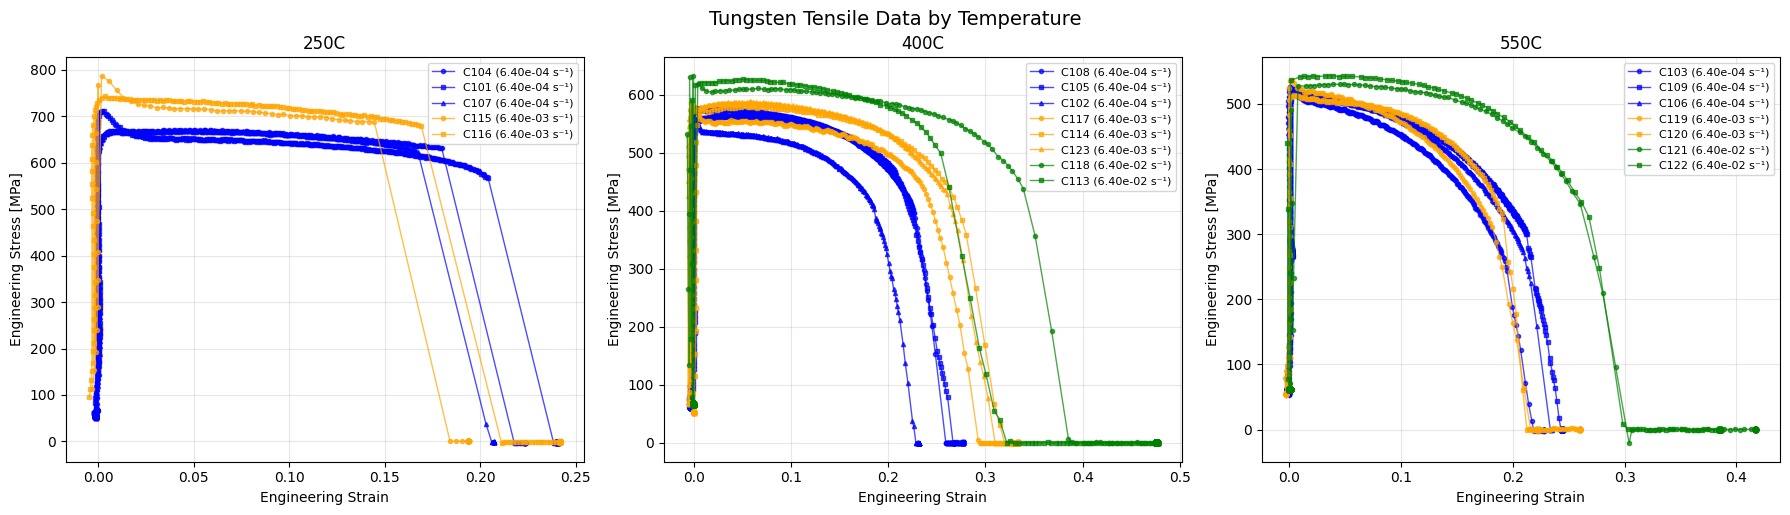

In [ ]:
path = '/home/colinmoose/neml2/cmg_projects/tensile_data/W_tensile_data'

# Process each CSV file individually and track strain rate
sample_data = []

for filename in os.listdir(path):
    if filename.endswith(".csv"):
        file_path = os.path.join(path, filename)
        df = pd.read_csv(file_path)
        
        # Extract sample name (e.g., 'C101' from 'W_C101_250C.csv')
        sample_name = filename.split('_')[1]  # Gets 'C101'
        
        # Determine temperature and strain rate
        if '250C' in filename:
            temp = 250
            temp_label = '250C'
            if sample_name in ['C101', 'C104', 'C107']:
                strain_rate = 6.4e-4
            elif sample_name in ['C115', 'C116']:
                strain_rate = 6.4e-3
            else:
                strain_rate = None
        elif '400C' in filename:
            temp = 400
            temp_label = '400C'
            if sample_name in ['C102', 'C105', 'C108']:
                strain_rate = 6.4e-4
            elif sample_name in ['C114', 'C117', 'C123']:
                strain_rate = 6.4e-3
            elif sample_name in ['C113', 'C118']:
                strain_rate = 6.4e-2
            else:
                strain_rate = None
        elif '550C' in filename:
            temp = 550
            temp_label = '550C'
            if sample_name in ['C103', 'C106', 'C109']:
                strain_rate = 6.4e-4
            elif sample_name in ['C119', 'C120']:
                strain_rate = 6.4e-3
            elif sample_name in ['C121', 'C122']:
                strain_rate = 6.4e-2
            else:
                strain_rate = None
        else:
            temp_label = 'unknown'
            temp = None
            strain_rate = None
        
        # Convert to torch tensors
        strain = torch.tensor(df['x'].values, device=device)
        stress = torch.tensor(df['y'].values, device=device)
        
        # Sort by strain
        sorted_idx = torch.argsort(strain)
        strain = strain[sorted_idx]
        stress = stress[sorted_idx]
        
        # Store the processed data
        sample_data.append({
            'sample': sample_name,
            'filename': filename,
            'temp': temp,
            'temp_label': temp_label,
            'strain_rate': strain_rate,
            'strain': strain,
            'stress': stress
        })

# Print sample info
print('--- Sample Information ---')
for data in sorted(sample_data, key=lambda x: (x['temp'] or 0, x['strain_rate'] or 0)):
    sr_str = f"{data['strain_rate']:.2e}" if data['strain_rate'] else "Unknown"
    n_points = len(data['strain'])
    print(f"{data['sample']}: {data['temp']}C, strain rate = {sr_str}, n_points = {n_points}")

# Create separate plots for each temperature
temps = ['250C', '400C', '550C']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, temp_label in enumerate(temps):
    ax = axes[idx]
    
    # Filter data for this temperature
    temp_samples = [s for s in sample_data if s['temp_label'] == temp_label]
    
    # Group by strain rate for coloring
    strain_rate_groups = {}
    for sample in temp_samples:
        sr = sample['strain_rate']
        if sr not in strain_rate_groups:
            strain_rate_groups[sr] = []
        strain_rate_groups[sr].append(sample)
    
    # Plot each strain rate group with different colors
    colors = {6.4e-4: 'blue', 6.4e-3: 'orange', 6.4e-2: 'green'}
    markers = ['o', 's', '^', 'v', '<', '>', 'd', 'p']
    
    for sr_idx, (strain_rate, samples) in enumerate(sorted(strain_rate_groups.items(), key=lambda x: x[0] if x[0] else 0)):
        for sample_idx, sample in enumerate(samples):
            strain_np = sample['strain'].cpu().numpy()
            stress_np = sample['stress'].cpu().numpy()
            
            sr_label = f"{strain_rate:.2e} s⁻¹" if strain_rate else "Unknown"
            label = f"{sample['sample']} ({sr_label})"
            color = colors.get(strain_rate, 'gray')
            marker = markers[sample_idx % len(markers)]
            
            ax.plot(strain_np, stress_np, 
                   marker=marker, markersize=3, linestyle='-', 
                   color=color, alpha=0.7, linewidth=1,
                   label=label)
    
    ax.set_xlabel('Engineering Strain')
    ax.set_ylabel('Engineering Stress [MPa]')
    # ax.set_xlim([-0.007, 0.005])
    ax.set_title(f'{temp_label}')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Tungsten Tensile Data by Temperature', y=1.02, fontsize=14)
plt.show()